# WEC Integration and Time Series Analysis
This notebook demonstrates WEC-Grid's core functionality for wave energy converter integration:
- Setting up a grid system with WEC devices
- Running time-domain simulations
- Analyzing WEC performance and grid impact

This example uses the IEEE 30 case system with RM3 wave energy converters.

In [1]:
import wecgrid

example2 = wecgrid.Engine()
example2.case("grid_models/IEEE_30_bus.raw")
example2.load(["pypsa"])
example2

Engine:
├─ Case: IEEE 30 bus
├─ PyPSA: Loaded
├─ PSS/E: Not Loaded
├─ WEC-Farms/WECs: 0 - 0
└─ Buses: 30

Sbase: 100.0 MVA

---
## Create WEC-Farm with a WEC Devices

Lets create a WEC Farm with a ten RM3 devices. The RM3 simulation data was pulled from the pre-loaded WEC-Grid database found here. Specifics about the RM3 run can be found in the documentation.

In [2]:
#Information about the wec-sim runs in database can accessed using 
example2.database.wecsim_runs()

,wec_sim_id,model_type,sim_duration_sec,delta_time,wave_height_m,wave_period_sec,wave_spectrum,wave_class,wave_seed,simulation_hash,created_at
0,2,LUPA,86400.0,0.1,2.5,8.0,PM,irregular,8,LUPA_2.5m_8.0s_8,2025-08-19 19:59:49
1,1,RM3,86400.0,0.1,2.5,8.0,PM,irregular,94,RM3_2.5m_8.0s_94,2025-08-19 19:45:01


In [3]:
example2.apply_wec(
   farm_name = "WEC-Farm-RM3",
   size = 10, # ten RM3 in WEC farm  
   wec_sim_id = 1, # RM3 run id  
   bus_location=31, # create a new bus for farm  
   connecting_bus = 1, # Connect to bus 1 or swing bus
)

WEC Farm added: WEC-Farm-RM3


---

## Review updated Grid

After added the WEC-Farm to the grid, we now have 31 Buses, 7 Generators, and 38 lines.

In [4]:
grid = example2.pypsa.grid
grid

GridState:
├─ Components:
│   ├─ bus:   31 components
│   ├─ gen:   7 components
│   ├─ line:  38 components
│   └─ load:  21 components
├─ Case: IEEE 30 bus
└─ Modeler: pypsa

We can call the Single Line Diagram (SLD) function to visualize the updated grid with the WEC-Farm added.

SLD Data Summary:
  Buses: 31
  Lines: 38
  Generators: 7
  Loads: 21


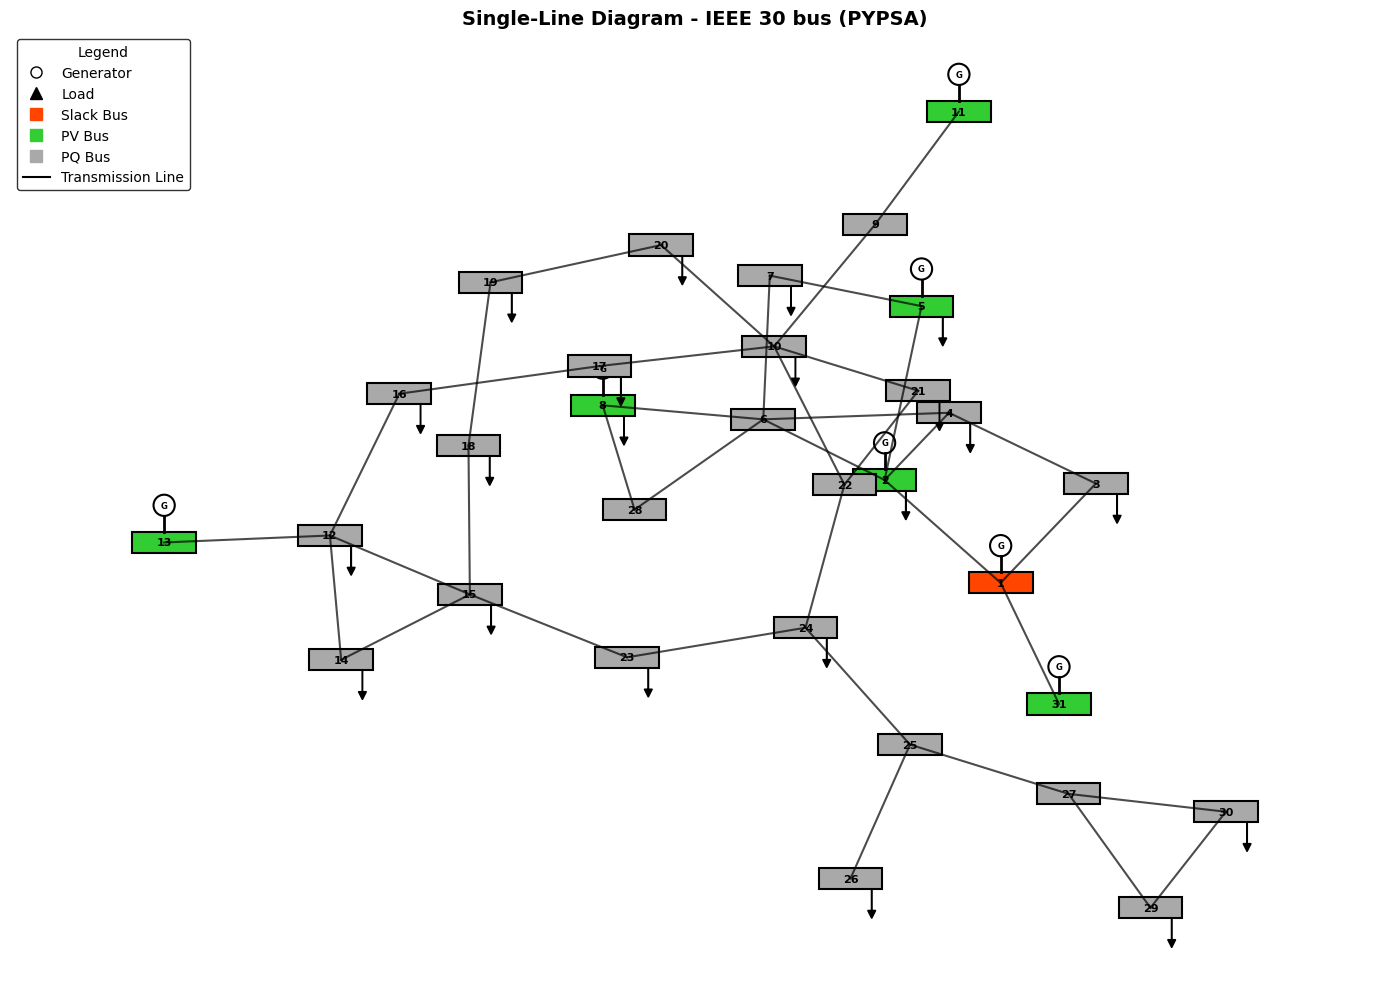

In [5]:
example2.plot.sld()

---

## Run Grid Simulation

Execute a time-domain simulation to analyze WEC power injection and grid response over 24 hours. 

In [6]:
example2.simulate() # takes some time!
example2.pypsa.report

PyPSA Simulating:   0%|          | 0/288 [00:00<?, ?step/s]

PyPSA Simulating: 100%|██████████| 288/288 [02:13<00:00,  2.16step/s]


SolveReport:
├─ Converged: Successful
├─ Simulation Time: 133.23 s
├─ Num Steps: 288
├─ Case: IEEE 30 bus
└─ Modeler: pypsa

---

## Analyze and Visualize Results

Create comprehensive plots to analyze WEC performance and grid impact over time.

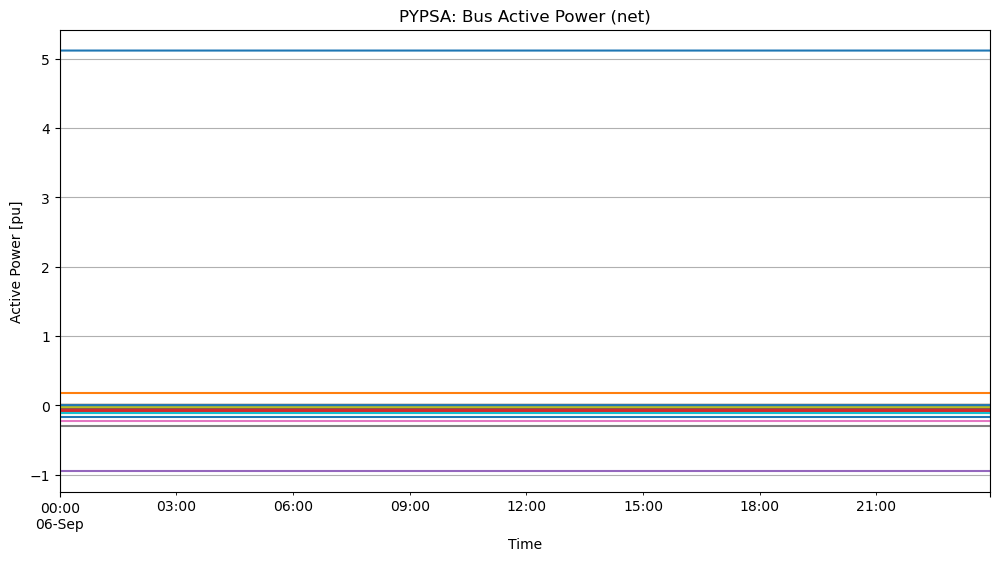

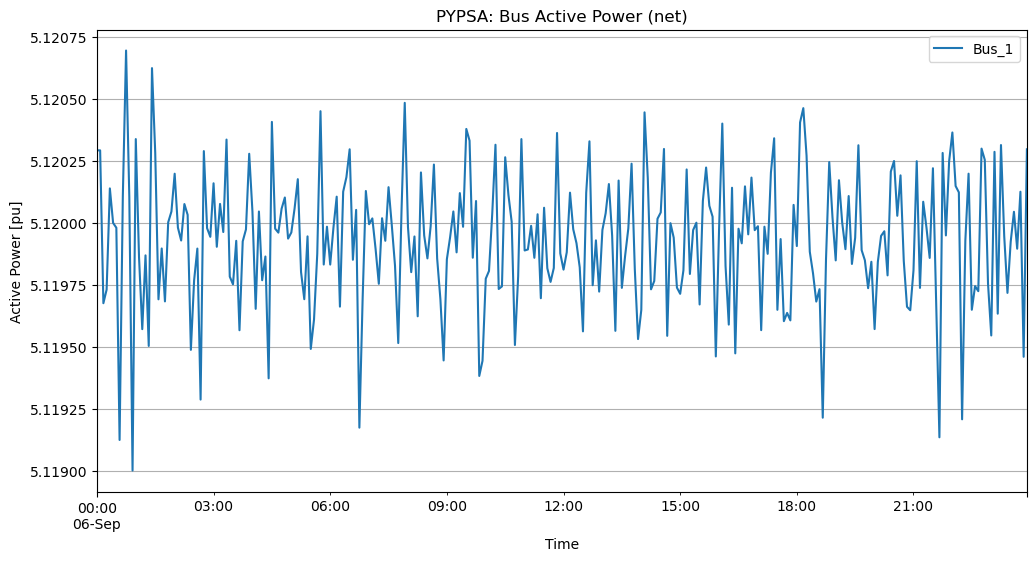

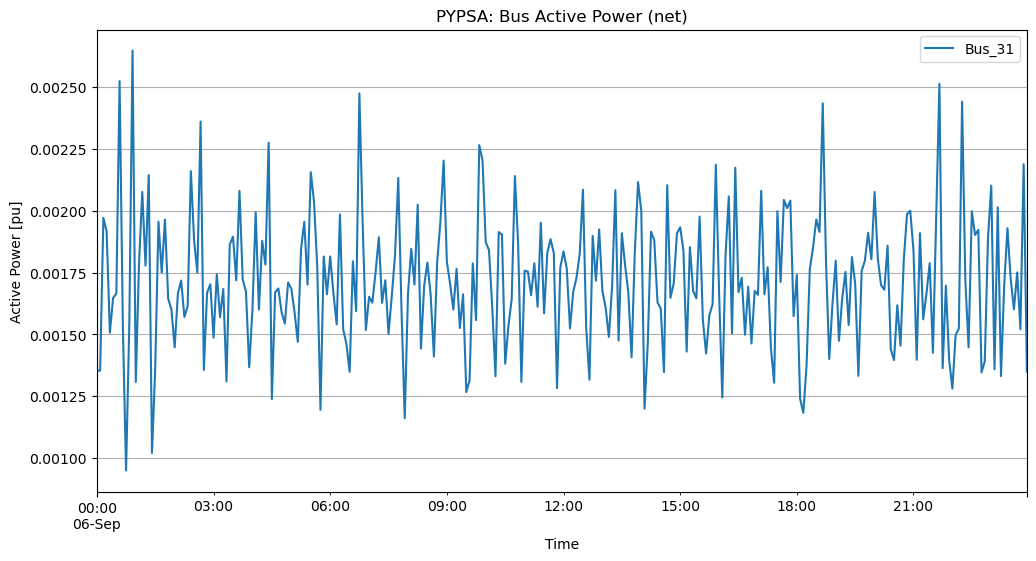

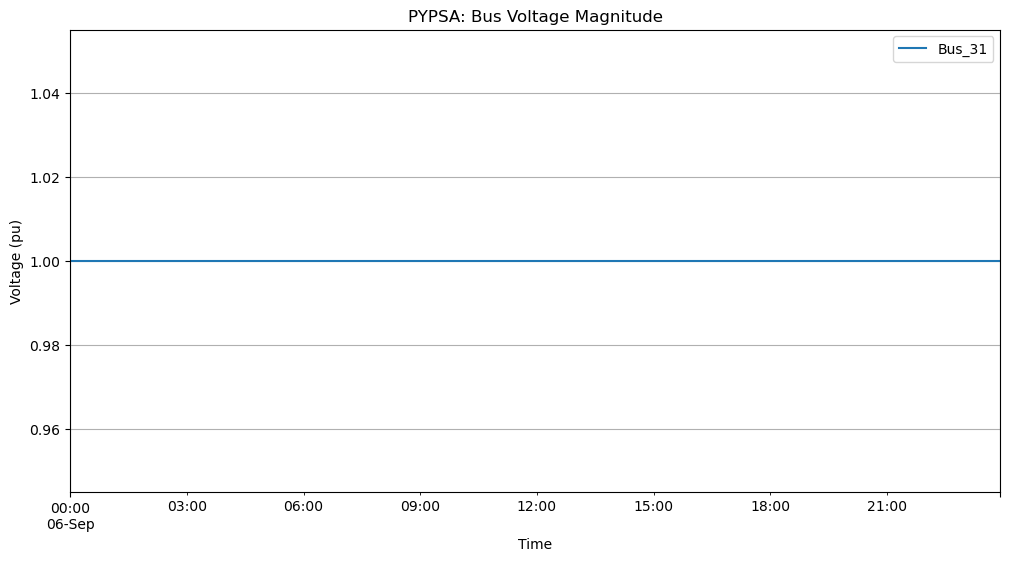

(<Figure size 1200x600 with 1 Axes>,
 <AxesSubplot:title={'center':'PYPSA: Bus Voltage Magnitude'}, xlabel='Time', ylabel='Voltage (pu)'>)

In [7]:
plot = example2.plot
plot.bus()
plot.bus(bus=['Bus_1']) # Swing Bus
plot.bus(bus=['Bus_31']) # WEC-Farm Bus
plot.bus(parameter='v_mag',bus=['Bus_31'])

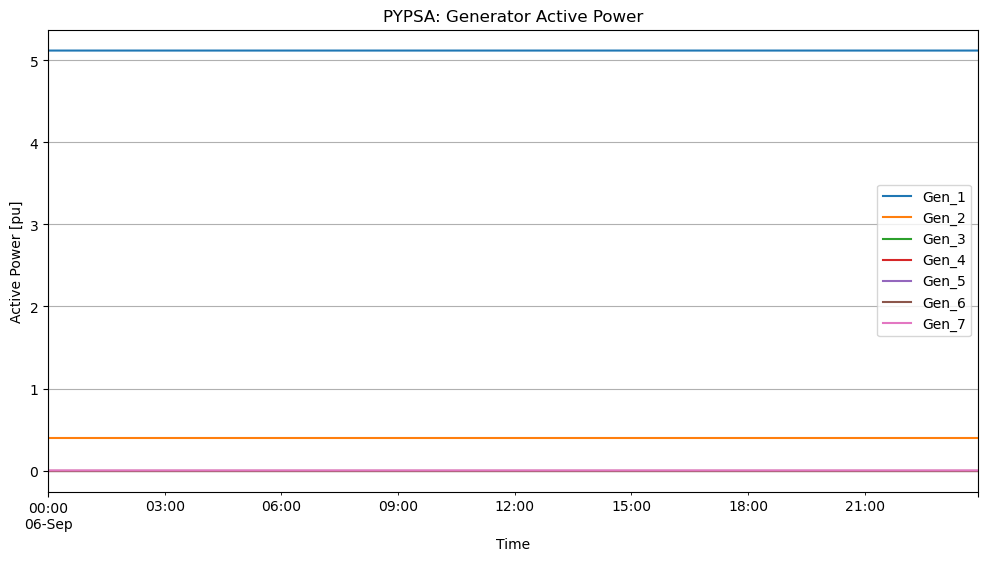

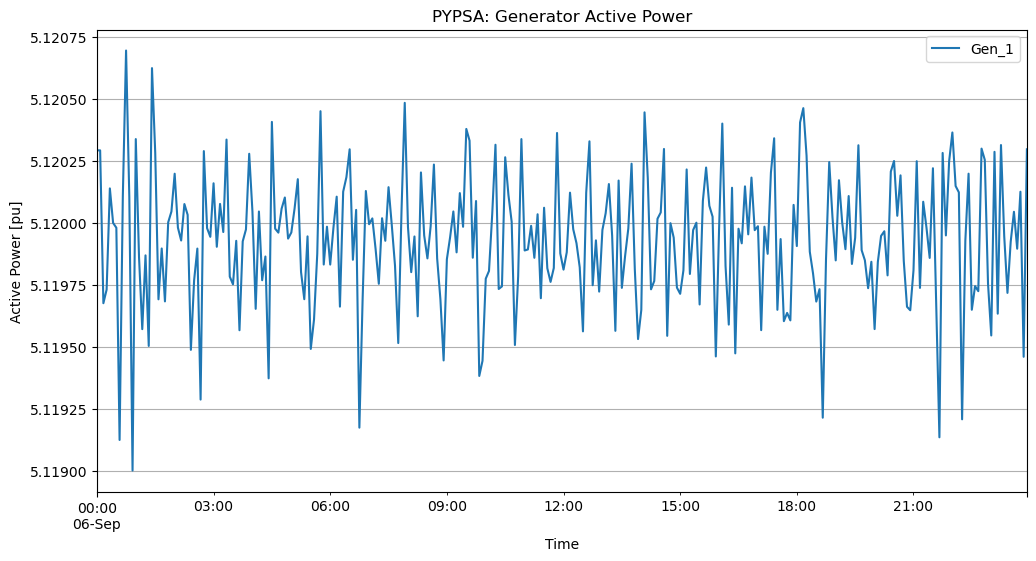

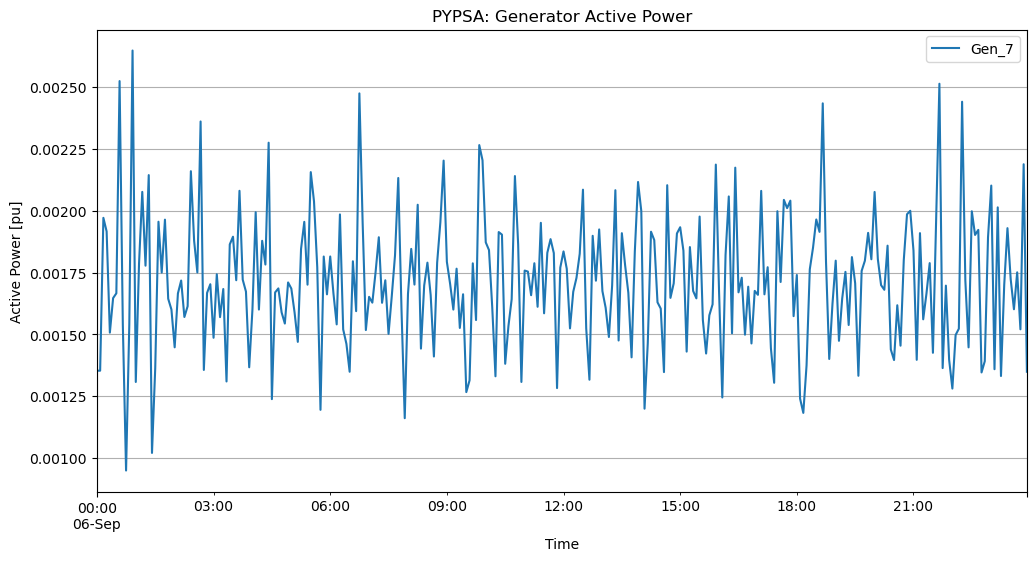

(<Figure size 1200x600 with 1 Axes>,
 <AxesSubplot:title={'center':'PYPSA: Generator Active Power'}, xlabel='Time', ylabel='Active Power [pu]'>)

In [8]:
plot.gen()
plot.gen(gen=['Gen_1']) # Swing Generator 
plot.gen(gen=['Gen_7']) # WEC-Farm Generator


Review our WEC-Farm 

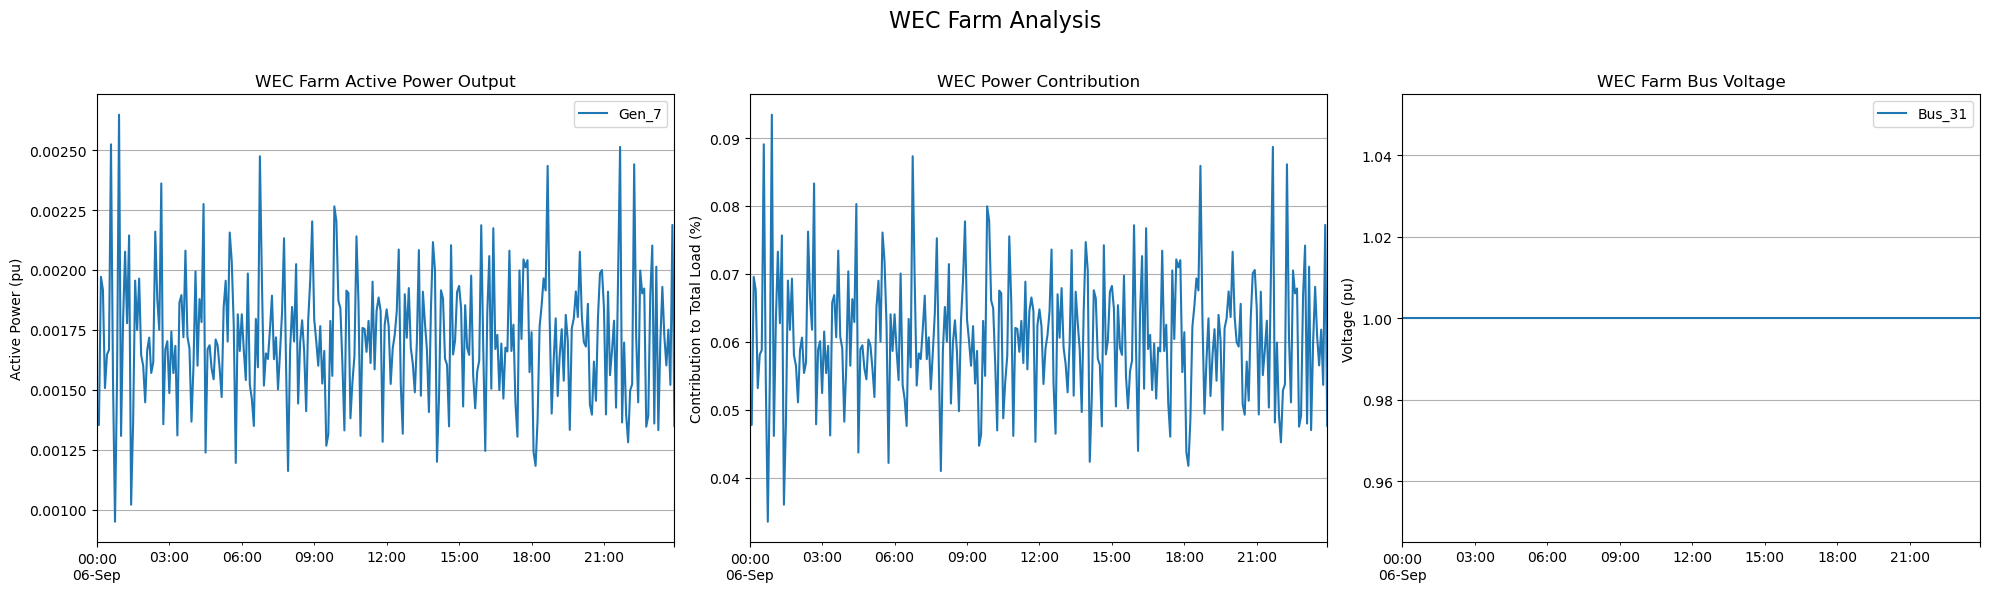

In [9]:
plot.wec_analysis()